# Learning the Precision on Fashion-MNIST and EMNIST

Experiments for the learned-precision extension of Possibilistic Variational Inference.
While the baseline CBOpt optimizers fix the candidate precision vartheta by hand,
here dispersion is learned variationally under an extremal-volume penalty (scale zeta = d/2):
isotropic and diagonal precisions via a damped Picard fixed point with anti-collapse and
positivity caps, and low-rank-plus-diagonal (LRD) and layer-wise block-diagonal (BD)
precisions via closed-form, sign-asymmetric safeguards. Sharpness-Aware Minimization (SAM)
is connected to the lower CBO (s = -1) via an indicator candidate and extended through
a Gaussian relaxation to extract an adaptive perturbation radius.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/MDV_spread')
!pwd

Mounted at /content/drive
/content/drive/MyDrive/MDV_spread


In [ ]:
import os
import sys
import time
import glob

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from src.model import LeNet
from src.data import get_fmnist_loaders, get_emnist_loader
from src.optimizers import build_optimizer
from src.train import train_model
from src.diagnostics import step_metrics
from src.evaluate import indomain_metrics, ood_metrics
from src import toy

# single config object
ROOT = os.path.abspath('.')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = os.path.join(ROOT, 'data')
CKPT_DIR = os.path.join(ROOT, 'checkpoints')
RES_DIR = os.path.join(ROOT, 'results')
FIG_DIR = os.path.join(ROOT, 'figs')
for d in (CKPT_DIR, RES_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

BENCH_EPOCHS = 100 # benchmark, 3 seeds
SHORT_EPOCHS = 50 # geometry check and SAM, 1 seed
WARMUP_EPOCHS = 5
BATCH_SIZE = 128
CBOPT_BETAS = dict(beta1=0.9, beta2=0.99999) # all CBOpt
# r < 1/(1+eps_rel) keeps the anti-collapse cap r-dependent (vartheta = hd_max/r); R_NOM_LOW = 0.5 sits in that regime, clear of the r in (0.833,1) floor-bound dead zone where the sweep would test nothing.
R_NOM_LOW = 0.5

# RUN_CONFIGS: opt/cfg feed build_optimizer directly; SAM runs lCBO-iso_1/2/3 (adaptive r) and SAM_1/2/3 (fixed rho, centered on rho_bar_nom from lCBO-iso_1).
RUN_CONFIGS = {
    # BENCHMARK -- s=+1, 3 seeds, 100 epochs
    'uCBOpt-iso': dict(opt='cbopt_iso', struct='iso', sign=+1, seeds=[0, 1, 2],
               epochs=BENCH_EPOCHS,
               cfg=dict(lr=1e-2, weight_decay=2e-3, hess_init=0.05, s=+1,
                        eps_rel=0.2, **CBOPT_BETAS)),
    'uCBOpt-diag': dict(opt='cbopt_diag', struct='diag', sign=+1, seeds=[0, 1, 2],
                  epochs=BENCH_EPOCHS,
                  cfg=dict(lr=1e-2, weight_decay=2e-3, hess_init=0.05, s=+1,
                           eps_rel=0.2, **CBOPT_BETAS)),
    'uCBOpt-BD': dict(opt='cbopt_block', struct='block', sign=+1, seeds=[0, 1, 2],
                   epochs=BENCH_EPOCHS,
                   cfg=dict(lr=1e-2, weight_decay=2e-3, hess_init=0.05, s=+1,
                            a=1.0, **CBOPT_BETAS)),
    # GEOMETRY CHECK -- s=-1, 1 seed, 50 epochs, diagnostics only
    'lCBOpt-LRD': dict(opt='cbopt_lrd', struct='lrd', sign=-1, seeds=[0],
                 epochs=SHORT_EPOCHS,
                 cfg=dict(lr=2e-3, weight_decay=2e-3, hess_init=0.1, s=-1,
                          a=1.0, **CBOPT_BETAS)),
    'lCBOpt-BD': dict(opt='cbopt_block', struct='block', sign=-1, seeds=[0],
                   epochs=SHORT_EPOCHS,
                   cfg=dict(lr=2e-3, weight_decay=2e-3, hess_init=0.1, s=-1,
                            a=1.0, **CBOPT_BETAS)),
    # SAM -- 6 runs, 1 seed, 50 epochs each
    'lCBO-iso_1': dict(opt='cbopt_iso', struct='iso', sign=-1, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='adapt', r_mult=1.0, # r = 0.500
               cfg=dict(lr=2e-3, weight_decay=2e-3, hess_init=0.1, s=-1,
                        eps_rel=0.2, **CBOPT_BETAS)),
    'lCBO-iso_2': dict(opt='cbopt_iso', struct='iso', sign=-1, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='adapt', r_mult=0.95, # r = 0.475
               cfg=dict(lr=2e-3, weight_decay=2e-3, hess_init=0.1, s=-1,
                        eps_rel=0.2, **CBOPT_BETAS)),
    'lCBO-iso_3': dict(opt='cbopt_iso', struct='iso', sign=-1, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='adapt', r_mult=1.05, # r = 0.525
               cfg=dict(lr=2e-3, weight_decay=2e-3, hess_init=0.1, s=-1,
                        eps_rel=0.2, **CBOPT_BETAS)),
    'SAM_1': dict(opt='sam', struct='sam', sign=None, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='fixed', rho_mult=1.0,
               cfg=dict(lr=5e-3, momentum=0.9, weight_decay=1e-5)),
    'SAM_2': dict(opt='sam', struct='sam', sign=None, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='fixed', rho_mult=0.95,
               cfg=dict(lr=5e-3, momentum=0.9, weight_decay=1e-5)),
    'SAM_3': dict(opt='sam', struct='sam', sign=None, seeds=[0], epochs=SHORT_EPOCHS,
               sam_kind='fixed', rho_mult=1.05,
               cfg=dict(lr=5e-3, momentum=0.9, weight_decay=1e-5)),
}

METRIC_COLS = ['Acc', 'NLL', 'ECE', 'FPR@95', 'AUROC']

# Baselines reused verbatim from the reproduction (same environment, no rerun).
BASELINES_REPRO = {
    'uCBOpt': ['0.909 +/- 0.002', '0.272 +/- 0.004', '0.025 +/- 0.001',
               '0.263 +/- 0.005', '0.795 +/- 0.005'],
    'AdamW':  ['0.896 +/- 0.003', '0.296 +/- 0.005', '0.022 +/- 0.006',
               '0.335 +/- 0.005', '0.722 +/- 0.016'],
    'IVON':   ['0.910 +/- 0.002', '0.258 +/- 0.003', '0.019 +/- 0.001',
               '0.241 +/- 0.009', '0.812 +/- 0.012'],
}

print('device:', DEVICE)

device: cuda


In [ ]:
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def loaders(seed: int):
    return get_fmnist_loaders(DATA_DIR, batch_size=BATCH_SIZE, val_fraction=0.1, seed=seed)


def RUN_EPOCHS(run_id: str) -> int:
    return RUN_CONFIGS[run_id]['epochs']


def ckpt_paths(run_id: str, seed: int):
    rc = RUN_CONFIGS[run_id]
    sign = {1: 'splus', -1: 'sminus', None: 'none'}[rc['sign']]
    stem = f"{run_id.lower()}_{rc['struct']}_{sign}_seed{seed}"
    return (os.path.join(CKPT_DIR, stem + '.pt'),
            os.path.join(CKPT_DIR, stem + '_history.csv'))


def perstep_path(run_id: str, seed: int):
    return ckpt_paths(run_id, seed)[0].replace('.pt', '_perstep.csv')


def save_unit(pt, csv, run_id, seed, model, optimizer, history):
    payload = dict(model=model.state_dict(), epoch=len(history), seed=seed,
                   run_id=run_id, config=RUN_CONFIGS[run_id], history=history)
    if optimizer is not None:
        payload['opt'] = optimizer.state_dict()
    torch.save(payload, pt)
    df = pd.DataFrame(history)
    df.insert(0, 'run_id', run_id)
    df.insert(1, 'seed', seed)
    df.to_csv(csv, index=False)
    print(f'  saved {os.path.basename(pt)} ({len(history)} epochs)')


_RHO_BAR = {}

def rho_bar_nom() -> float:
    # Temporal mean of rho*_t = vartheta_t^-1/2 along lCBO-iso_1, from its per-step log.
    if 'v' not in _RHO_BAR:
        ps = perstep_path('lCBO-iso_1', 0)
        assert os.path.exists(ps), 'train lCBO-iso_1 first (its per-step log feeds rho_bar_nom).'
        vth = pd.read_csv(ps)['vartheta'].values
        _RHO_BAR['v'] = float(np.mean(vth ** -0.5))
    return _RHO_BAR['v']


def train_run(run_id: str):
    # Resume-safe training of every seed of one run (checkpoint check first).
    rc = RUN_CONFIGS[run_id]
    for seed in rc['seeds']:
        pt, csv = ckpt_paths(run_id, seed)
        if os.path.exists(pt):
            print(f'{run_id} seed={seed} - checkpoint exists, skipping.')
            continue
        n_epochs = RUN_EPOCHS(run_id)
        cfg = dict(rc['cfg'])
        extra = ''
        if rc.get('sam_kind') == 'adapt':
            cfg['r'] = R_NOM_LOW * rc['r_mult']
            extra = f", r={cfg['r']:.2e}"
        elif rc.get('sam_kind') == 'fixed':
            cfg['rho'] = rho_bar_nom() * rc['rho_mult']
            extra = f", rho={cfg['rho']:.4g}"
        print(f'{run_id} seed={seed} - training ({rc["opt"]}, sign={rc["sign"]}, '
              f'{n_epochs} epochs{extra})...')
        set_seed(seed)
        tr, va, _ = loaders(seed)
        model = LeNet(num_classes=10, dropout=0.0).to(DEVICE)
        optimizer = build_optimizer(rc['opt'], model.parameters(), **cfg)
        hook = (lambda o: step_metrics(o)) if rc['opt'].startswith('cbopt') else None
        ps = perstep_path(run_id, seed) if run_id == 'lCBO-iso_1' else None
        model, history = train_model(
            model, optimizer, tr, va, epochs=n_epochs, warmup_epochs=WARMUP_EPOCHS,
            device=DEVICE, verbose=True, patience=9999, diag_hook=hook, perstep_csv=ps)
        save_unit(pt, csv, run_id, seed, model, optimizer, history)


def evaluate_run(run_id: str):
    # Load each seed's checkpoint, compute in-domain + OOD metrics.
    rc = RUN_CONFIGS[run_id]
    _, _, te = loaders(0)
    ood = get_emnist_loader(DATA_DIR)
    rows = []
    for seed in rc['seeds']:
        pt, _ = ckpt_paths(run_id, seed)
        if not os.path.exists(pt):
            print(f'{run_id} seed={seed} - no checkpoint, skipping.')
            continue
        model = LeNet(num_classes=10, dropout=0.0).to(DEVICE)
        model.load_state_dict(torch.load(pt, map_location=DEVICE)['model'])
        model.eval()
        m = {}
        m.update(indomain_metrics(model, te, DEVICE))
        m.update(ood_metrics(model, te, ood, DEVICE))
        rows.append(dict(run_id=run_id, seed=seed, **m))
        print(f'{run_id} seed={seed}: ' + ', '.join(f'{k}={m[k]:.4f}' for k in METRIC_COLS))
    return rows


def run_accuracy(run_id: str, seed: int = 0) -> float:
    pt, _ = ckpt_paths(run_id, seed)
    if not os.path.exists(pt):
        return float('nan')
    _, _, te = loaders(0)
    model = LeNet(num_classes=10, dropout=0.0).to(DEVICE)
    model.load_state_dict(torch.load(pt, map_location=DEVICE)['model'])
    model.eval()
    return float(indomain_metrics(model, te, DEVICE)['Acc'])


def hist(run_id: str, seed: int = 0):
    # Load a *_history.csv ; rename legacy iso column names to the current ones.
    _, csv = ckpt_paths(run_id, seed)
    if not os.path.exists(csv):
        return None
    df = pd.read_csv(csv)
    return df.rename(columns={'hs_pos_real': 'hs_pos_raw', 'hs_margin_real': 'hs_margin_raw',
                              'hs_pos_cf': 'hs_pos_raw_cf', 'hs_margin_cf': 'hs_margin_raw_cf'})

In [ ]:
def fmt(vals):
    a = np.asarray(vals, dtype=float)
    return f'{a.mean():.3f} +/- {a.std():.3f}'

In [ ]:
# uCBOpt-BD seed 2 diverged at epoch 16 (near-singular block solve, Appendix app:setup); excluded from every aggregate below.
EXCLUDED_SEEDS = {'uCBOpt-BD': [2]}

def agg_seeds(run_id):
    excl = set(EXCLUDED_SEEDS.get(run_id, []))
    return [s for s in RUN_CONFIGS[run_id]['seeds'] if s not in excl]

for _rid, _ex in EXCLUDED_SEEDS.items():
    print(f'{_rid}: aggregation uses seeds {agg_seeds(_rid)}  (excluded: {_ex} -- diverged epoch 16)')

uCBOpt-BD: aggregation uses seeds [0, 1]  (excluded: [2] -- diverged epoch 16)


## Setup 

In [ ]:
_emnist_ok = os.path.exists(os.path.join(DATA_DIR, 'EMNIST', 'raw', 'emnist-letters-test-images-idx3-ubyte'))
if _emnist_ok:
    print('EMNIST present -- skipping download.')
else:
    os.makedirs(os.path.join(DATA_DIR, 'EMNIST', 'raw'), exist_ok=True)
    !curl -L -o {DATA_DIR}/EMNIST/raw/gzip.zip https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip
    !cd {DATA_DIR}/EMNIST/raw && unzip -o gzip.zip
    !cp {DATA_DIR}/EMNIST/raw/gzip/emnist-letters-*.gz {DATA_DIR}/EMNIST/raw/
    !gunzip -fk {DATA_DIR}/EMNIST/raw/emnist-letters-*.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  535M  100  535M    0     0  59.2M      0  0:00:09  0:00:09 --:--:-- 47.6M
Archive:  gzip.zip
  inflating: gzip/emnist-balanced-mapping.txt  
  inflating: gzip/emnist-balanced-test-images-idx3-ubyte.gz  
 extracting: gzip/emnist-balanced-test-labels-idx1-ubyte.gz  
  inflating: gzip/emnist-balanced-train-images-idx3-ubyte.gz  
  inflating: gzip/emnist-balanced-train-labels-idx1-ubyte.gz  
  inflating: gzip/emnist-byclass-mapping.txt  
  inflating: gzip/emnist-byclass-test-images-idx3-ubyte.gz  
  inflating: gzip/emnist-byclass-test-labels-idx1-ubyte.gz  
  inflating: gzip/emnist-byclass-train-images-idx3-ubyte.gz  
  inflating: gzip/emnist-byclass-train-labels-idx1-ubyte.gz  
  inflating: gzip/emnist-bymerge-mapping.txt  
  inflating: gzip/emnist-bymerge-test-images-idx3-ubyte.gz  
  inflating: gzip/emnist-bymerge-test-labels-

## TOY (closed form, no training)

Isotropic quadratic `l(theta) = 1/2 (theta-mu)^T A (theta-mu)` with an L2 prior of
precision `delta` (`src/toy.py`). All quantities are closed forms. No L_Phi here
(L_Phi is a real-network diagnostic, Section on L_Phi below).

In [ ]:
# Sweep vartheta at fixed eta, two regimes: existence, monotonicity, penalty, SAM direction
rng = np.random.default_rng(0)
D = 30
A_DIAG = np.exp(rng.uniform(-1.5, 1.5, D))
MU = rng.normal(0.0, 1.0, D)
DELTA = 2e-3
Q = toy.ToyQuadratic(a=A_DIAG, mu=MU, delta=DELTA)
m_bound, M_bound = float(Q.hd.min()), float(Q.hd.max())

REGIMES = {'far': MU + rng.normal(0.0, 1.5, D), 'near': MU + 1e-2 * rng.normal(0.0, 1.0, D)}

for name, eta in REGIMES.items():
    print(f'\nregime {name}')
    for s in (+1, -1):
        lo = 1e-4 * m_bound if s == +1 else M_bound * (1 + 1e-3)
        hi = m_bound * (1 - 1e-3) if s == +1 else 50 * M_bound
        grid = np.geomspace(lo, hi, 400)
        u_norm = np.array([np.linalg.norm(toy.u_iso(Q, eta, v, s)) for v in grid])
        cont = np.all(np.isfinite(u_norm)) and np.all(u_norm > 0)
        raw = np.array([toy.cbo_iso(Q, eta, v, s) for v in grid])
        raw_monotone = np.all(np.diff(raw) > -1e-9) or np.all(np.diff(raw) < 1e-9)
        vstar = toy.stationary_vartheta_iso(Q, eta, s)
        interior = grid[0] < vstar < grid[-1]
        print(f'  s={s:+d}: u_s>0 everywhere={cont}  raw CBO_s monotone={raw_monotone}  '
              f'penalized interior stationary vartheta*={vstar:.4g} (interior={interior})')

eta = REGIMES['far']
for s in (+1, -1):
    print(f'\ncoefficient zeta sensitivity (s={s:+d})')
    for factor in (0.25, 0.5, 1.0, 2.0, 4.0):
        zeta = factor * D / 2.0
        vstar = toy.stationary_vartheta_iso(Q, eta, s, zeta=zeta)
        print(f'  zeta = {factor:>4}*d/2 : vartheta* = {vstar:.5g}  '
              f'(sign_cond={toy.sign_condition(Q, vstar, s)})')

vstar = toy.stationary_vartheta_iso(Q, eta, -1)
for rho in (0.05, 0.2, 1.0):
    e_sam = toy.sam_perturbation(Q, eta, rho)
    u_soft = toy.u_soft(Q, eta, vstar)
    cos = float(e_sam @ u_soft / (np.linalg.norm(e_sam) * np.linalg.norm(u_soft)))
    print(f'  rho={rho}: cos(eps*_SAM, u*_soft)={cos:.6f}  '
          f'||eps*_SAM||={np.linalg.norm(e_sam):.4g}  ||u*_soft||={np.linalg.norm(u_soft):.4g}  '
          f'induced rho_alpha=vartheta*^-1/2={toy.induced_radius(vstar):.4g}')


regime far
  s=+1: u_s>0 everywhere=True  raw CBO_s monotone=True  penalized interior stationary vartheta*=0.1635 (interior=True)
  s=-1: u_s>0 everywhere=True  raw CBO_s monotone=True  penalized interior stationary vartheta*=18.18 (interior=True)

regime near
  s=+1: u_s>0 everywhere=True  raw CBO_s monotone=True  penalized interior stationary vartheta*=0.2265 (interior=True)
  s=-1: u_s>0 everywhere=True  raw CBO_s monotone=True  penalized interior stationary vartheta*=4.471 (interior=True)

coefficient zeta sensitivity (s=+1)
  zeta = 0.25*d/2 : vartheta* = 0.074187  (sign_cond=True)
  zeta =  0.5*d/2 : vartheta* = 0.11948  (sign_cond=True)
  zeta =  1.0*d/2 : vartheta* = 0.16352  (sign_cond=True)
  zeta =  2.0*d/2 : vartheta* = 0.19271  (sign_cond=True)
  zeta =  4.0*d/2 : vartheta* = 0.20869  (sign_cond=True)

coefficient zeta sensitivity (s=-1)
  zeta = 0.25*d/2 : vartheta* = 55.077  (sign_cond=True)
  zeta =  0.5*d/2 : vartheta* = 30.554  (sign_cond=True)
  zeta =  1.0*d/2 : va

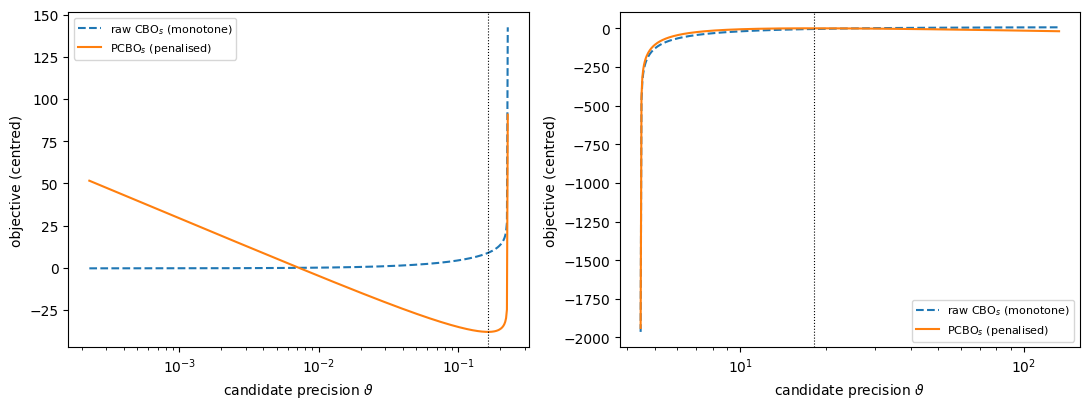

In [ ]:
# TOY Figure: the log-volume penalty repairs the degeneracy
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
eta = REGIMES['far']
for ax, s in zip(axes, (+1, -1)):
    lo = 1e-3 * m_bound if s == +1 else M_bound * (1 + 1e-3)
    hi = m_bound * (1 - 1e-3) if s == +1 else 30 * M_bound
    grid = np.geomspace(lo, hi, 500)
    raw = np.array([toy.cbo_iso(Q, eta, v, s) for v in grid])
    pen = np.array([toy.pcbo_iso(Q, eta, v, s) for v in grid])
    ax.plot(grid, raw - raw[len(grid) // 2], '--', label='raw $\\mathrm{CBO}_s$ (monotone)')
    ax.plot(grid, pen - pen[len(grid) // 2], '-', label='$\\mathrm{PCBO}_s$ (penalized)')
    vstar = toy.stationary_vartheta_iso(Q, eta, s)
    ax.axvline(vstar, color='k', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('candidate precision $\\vartheta$')
    ax.set_ylabel('objective (centred)')
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'toy_penalty_repair.png'), dpi=130)
plt.show()

In [ ]:
# Dimension sweep, per-step time (Prop complexity), averaged over n_repeats independent runs
import torch.nn as nn

def _mlp(width):
    return nn.Sequential(nn.Linear(64, width), nn.ReLU(), nn.Linear(width, width),
                         nn.ReLU(), nn.Linear(width, 10))

widths = [32, 64, 128, 256, 400]
n_steps = 30
n_repeats = 6
x = torch.randn(32, 64)
y = torch.randint(0, 10, (32,))
rows = []
for w in widths:
    d = sum(p.numel() for p in _mlp(w).parameters())
    for opt_name in ('cbopt_iso', 'cbopt_diag', 'cbopt_lrd', 'cbopt_block'):
        samples = []
        for rep in range(n_repeats):
            torch.manual_seed(rep)
            model = _mlp(w)
            opt = build_optimizer(opt_name, model.parameters(), lr=1e-3, s=+1, weight_decay=2e-3)
            for _ in range(3):
                opt.zero_grad(); nn.CrossEntropyLoss()(model(x), y).backward(); opt.step()
            t0 = time.perf_counter()
            for _ in range(n_steps):
                opt.zero_grad(); nn.CrossEntropyLoss()(model(x), y).backward(); opt.step()
            samples.append(1e3 * (time.perf_counter() - t0) / n_steps)
        rows.append(dict(d=d, optimizer=opt_name, ms_mean=float(np.mean(samples)),
                         ms_std=float(np.std(samples))))
tim = pd.DataFrame(rows)
print(f'mean ms/step over {n_repeats} independent runs:')
print(tim.pivot(index='d', columns='optimizer', values='ms_mean').round(3))
print('\nstd ms/step:')
print(tim.pivot(index='d', columns='optimizer', values='ms_std').round(3))

mean ms/step over 6 independent runs:
optimizer  cbopt_block  cbopt_diag  cbopt_iso  cbopt_lrd
d                                                       
3466             2.296       3.859      3.273      1.466
8970             2.327       4.204      3.241      1.632
26122            3.632       7.129      3.881      2.395
85002            3.498       7.964      8.068      2.750
190410           5.281      12.009     10.047      5.045

std ms/step:
optimizer  cbopt_block  cbopt_diag  cbopt_iso  cbopt_lrd
d                                                       
3466             0.115       0.315      0.171      0.036
8970             0.151       0.308      0.111      0.182
26122            0.211       0.269      0.341      0.106
85002            0.062       2.010      0.550      0.204
190410           0.240       0.419      0.714      0.503


## Benchmark training: CBOpt iso / diag / block, s=+1

LeNet-5 / Fashion-MNIST, batch 128, 100 epochs, warmup 5 + cosine, 3 seeds.
Resume-safe: each cell checks its checkpoint before training. uCBOpt-iso is already
trained -- its cell just skips. The comparison table is in the last section.

In [ ]:
train_run('uCBOpt-iso')

In [ ]:
train_run('uCBOpt-diag')

uCBOpt-diag seed=0 - training (cbopt_diag, sign=1, 100 epochs)...
epoch 1/100 train=0.8028 val=0.5051 best=0.5051
epoch 10/100 train=0.3598 val=0.3443 best=0.3443
epoch 20/100 train=0.3496 val=0.3462 best=0.3309
epoch 30/100 train=0.3305 val=0.3693 best=0.3309
epoch 40/100 train=0.3204 val=0.3412 best=0.3299
epoch 50/100 train=0.3031 val=0.3318 best=0.3058
epoch 60/100 train=0.2682 val=0.3128 best=0.2947
epoch 70/100 train=0.2392 val=0.3011 best=0.2760
epoch 80/100 train=0.1975 val=0.2678 best=0.2620
epoch 90/100 train=0.1461 val=0.2447 best=0.2447
epoch 100/100 train=0.1143 val=0.2455 best=0.2443
  saved ucbopt-diag_diag_splus_seed0.pt (100 epochs)
uCBOpt-diag seed=1 - training (cbopt_diag, sign=1, 100 epochs)...
epoch 1/100 train=0.7513 val=0.4756 best=0.4756
epoch 10/100 train=0.3573 val=0.3672 best=0.3456
epoch 20/100 train=0.3472 val=0.3803 best=0.3456
epoch 30/100 train=0.3326 val=0.3797 best=0.3355
epoch 40/100 train=0.3227 val=0.3423 best=0.3204
epoch 50/100 train=0.2986 val=0.

In [ ]:
train_run('uCBOpt-BD')

uCBOpt-BD seed=0 - training (cbopt_block, sign=1, 100 epochs)...
epoch 1/100 train=0.6730 val=0.4279 best=0.4279
epoch 10/100 train=0.4566 val=0.4872 best=0.3858
epoch 20/100 train=0.4677 val=0.4388 best=0.3858
epoch 30/100 train=0.4647 val=0.4880 best=0.3858
epoch 40/100 train=0.4354 val=0.5361 best=0.3858
epoch 50/100 train=0.4092 val=0.4185 best=0.3858
epoch 60/100 train=0.3695 val=0.3912 best=0.3653
epoch 70/100 train=0.3234 val=0.3573 best=0.3320
epoch 80/100 train=0.2723 val=0.3337 best=0.3163
epoch 90/100 train=0.2144 val=0.2693 best=0.2693
epoch 100/100 train=0.1642 val=0.2507 best=0.2505
  saved ucbopt-bd_block_splus_seed0.pt (100 epochs)
uCBOpt-BD seed=1 - training (cbopt_block, sign=1, 100 epochs)...
epoch 1/100 train=0.6456 val=0.4157 best=0.4157
epoch 10/100 train=0.4697 val=0.4299 best=0.4061
epoch 20/100 train=0.4827 val=0.4462 best=0.4061
epoch 30/100 train=0.4519 val=0.4380 best=0.4061
epoch 40/100 train=0.4453 val=0.4365 best=0.4002
epoch 50/100 train=0.4095 val=0.423

In [ ]:
# uCBOpt-BD seed-2 divergence diagnostic (existing checkpoints only, no writes)
_DELTA_BLK = RUN_CONFIGS['uCBOpt-BD']['cfg']['weight_decay']
_A_BLK = RUN_CONFIGS['uCBOpt-BD']['cfg']['a']
_CALM = [4, 5, 6, 7, 8, 9] # classifier.* blocks (stay calm)
_BOOM = [0, 1, 3] # features.0.weight, features.0.bias, features.3.bias

def _blk_state(seed):
    ck = torch.load(ckpt_paths('uCBOpt-BD', seed)[0], map_location='cpu')
    names = list(ck['model'].keys())
    rows = []
    for i in sorted(ck['opt']['state']):
        st = ck['opt']['state'][i]
        m_l = float((st['v'] + _DELTA_BLK).min())
        rows.append(dict(blk=i, name=names[i], numel=int(st['v'].numel()),
                         m_l=m_l, psi=float(st['psi_bd']),
                         p_diag_min=m_l - 1.0 / float(st['psi_bd'])))
    return pd.DataFrame(rows), int(ck['epoch'])

_s0, _e0 = _blk_state(0)
_s2, _e2 = _blk_state(2)
print(f'final checkpoint: epoch {_e0}')

print('calm blocks (classifier.*, idx 4-9): seed 0 vs seed 2')
_cmp = _s0[_s0.blk.isin(_CALM)][['blk', 'name', 'm_l', 'psi', 'p_diag_min']].merge(
       _s2[_s2.blk.isin(_CALM)][['blk', 'm_l', 'psi', 'p_diag_min']], on='blk',
       suffixes=('_s0', '_s2'))
print(_cmp.to_string(index=False))

print('\nexploding blocks (idx 0,1,3), final checkpoint')
print(_s2[_s2.blk.isin(_BOOM)][['blk', 'name', 'numel', 'm_l', 'psi', 'p_diag_min']].to_string(index=False))

print('\ninfeasible_frac (fraction of blocks with u_sq >= 1/M_l), epochs 12-20')
for _sd in (0, 1, 2):
    _h = hist('uCBOpt-BD', _sd)
    _seg = _h[(_h.epoch >= 12) & (_h.epoch <= 20)]
    print(f'seed {_sd}: ' + '  '.join(
        f'ep{int(r.epoch)}:{r.infeasible_frac:.2f}(loss {r.train_loss:.3g})' for _, r in _seg.iterrows()))

final checkpoint: epoch 100
calm blocks (classifier.*, idx 4-9): seed 0 vs seed 2
 blk                name   m_l_s0    psi_s0  p_diag_min_s0   m_l_s2    psi_s2  p_diag_min_s2
   4 classifier.1.weight 0.034768 29.761932       0.001168 0.034768 29.761932       0.001168
   5   classifier.1.bias 0.034768 29.761932       0.001168 0.034768 29.761929       0.001168
   6 classifier.3.weight 0.034768 29.761932       0.001168 0.034768 29.761932       0.001168
   7   classifier.3.bias 0.034768 29.761932       0.001168 0.034768 29.761932       0.001168
   8 classifier.5.weight 0.034768 29.761932       0.001168 0.034768 29.761880       0.001168
   9   classifier.5.bias 0.034779 29.753333       0.001169 0.035031 29.546192       0.001186

exploding blocks (idx 0,1,3), final checkpoint
 blk              name  numel          m_l      psi   p_diag_min
   0 features.0.weight    150 1.640837e+08 1.000000 1.640837e+08
   1   features.0.bias      6 1.077117e+09 1.000000 1.077117e+09
   3   features.3.bias  

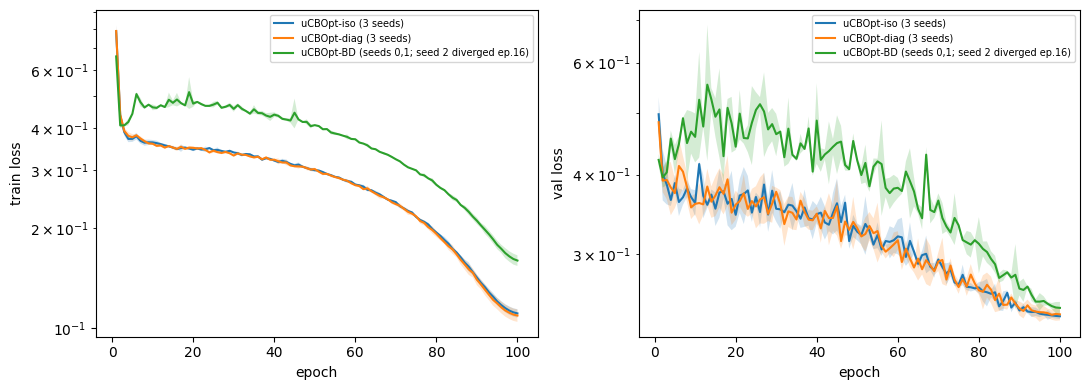

In [ ]:
# Benchmark averaged learning curves, uCBOpt-BD excludes seed 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for rid, lab in [('uCBOpt-iso', 'uCBOpt-iso'), ('uCBOpt-diag', 'uCBOpt-diag'),
                 ('uCBOpt-BD', 'uCBOpt-BD')]:
    sds = agg_seeds(rid)
    frames = [f for f in (hist(rid, s) for s in sds) if f is not None]
    if not frames:
        continue
    tag = ' (seeds 0,1; seed 2 diverged ep.16)' if rid == 'uCBOpt-BD' else f' ({len(sds)} seeds)'
    for ax, col in zip(axes, ('train_loss', 'val_loss')):
        big = pd.concat([f[['epoch', col]] for f in frames]).groupby('epoch')[col]
        mu, sd = big.mean(), big.std().fillna(0.0)
        ax.plot(mu.index, mu.values, label=lab + tag)
        ax.fill_between(mu.index, mu - sd, mu + sd, alpha=0.2)
for ax, ttl in zip(axes, ('train loss', 'val loss')):
    ax.set_xlabel('epoch'); ax.set_ylabel(ttl); ax.set_yscale('log'); ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'benchmark_learning_curves.png'), dpi=130)
plt.show()

## Benchmark result

CBOpt iso / diag / block at s=+1 (3 seeds each), plus the reproduction baselines
uCBOpt / AdamW / IVON (hard-coded, same environment, no rerun). No LRD, no s=-1,
no SAM here. uCBOpt-iso (iso, vartheta learned) is a distinct row from uCBOpt (vartheta fixed).

In [ ]:
TABLE_RUNS = {
    'CBOpt-iso s=+1 (uCBOpt-iso)': 'uCBOpt-iso',
    'CBOpt-diag s=+1':       'uCBOpt-diag',
    'CBOpt-block s=+1 (seed 2 excl.)': 'uCBOpt-BD',
}
all_raw, table_rows = [], {}
for label, rid in TABLE_RUNS.items():
    rows = [r for r in evaluate_run(rid) if r['seed'] in agg_seeds(rid)]
    if not rows:
        table_rows[label] = ['n/a'] * len(METRIC_COLS)
        continue
    all_raw.extend(dict(r, label=label) for r in rows)
    g = pd.DataFrame(rows)
    table_rows[label] = [fmt(g[c].values) for c in METRIC_COLS]

for label, vals in BASELINES_REPRO.items():
    table_rows[f'{label} (reproduction)'] = vals

order = ['CBOpt-iso s=+1 (uCBOpt-iso)', 'CBOpt-diag s=+1', 'CBOpt-block s=+1 (seed 2 excl.)',
         'uCBOpt (reproduction)', 'AdamW (reproduction)', 'IVON (reproduction)']
table = pd.DataFrame([table_rows[k] for k in order if k in table_rows],
                     index=[k for k in order if k in table_rows], columns=METRIC_COLS)
print(table.to_string())
print('\nNote: CBOpt-block s=+1 aggregates seeds 0 and 1 only -- seed 2 diverged '
      'numerically at epoch 16 (see the uCBOpt-BD seed-2 diagnostic cell).')
table.to_csv(os.path.join(RES_DIR, 'spread_summary.csv'))
if all_raw:
    pd.DataFrame(all_raw).to_csv(os.path.join(RES_DIR, 'spread_raw.csv'), index=False)

uCBOpt-iso seed=0: Acc=0.9134, NLL=0.2540, ECE=0.0215, FPR@95=0.2461, AUROC=0.8143
uCBOpt-iso seed=1: Acc=0.9107, NLL=0.2597, ECE=0.0227, FPR@95=0.2605, AUROC=0.7942
uCBOpt-iso seed=2: Acc=0.9121, NLL=0.2561, ECE=0.0224, FPR@95=0.2827, AUROC=0.7698
uCBOpt-diag seed=0: Acc=0.9159, NLL=0.2509, ECE=0.0207, FPR@95=0.2782, AUROC=0.7711
uCBOpt-diag seed=1: Acc=0.9128, NLL=0.2536, ECE=0.0232, FPR@95=0.3175, AUROC=0.7316
uCBOpt-diag seed=2: Acc=0.9152, NLL=0.2510, ECE=0.0174, FPR@95=0.2796, AUROC=0.7700
uCBOpt-BD seed=0: Acc=0.9057, NLL=0.2576, ECE=0.0142, FPR@95=0.2720, AUROC=0.7732
uCBOpt-BD seed=1: Acc=0.9094, NLL=0.2551, ECE=0.0132, FPR@95=0.3058, AUROC=0.7364
uCBOpt-BD seed=2: Acc=0.8422, NLL=0.4305, ECE=0.0337, FPR@95=0.2541, AUROC=0.7849
                                             Acc              NLL              ECE           FPR@95            AUROC
CBOpt-iso s=+1 (uCBOpt-iso)              0.912 +/- 0.001  0.257 +/- 0.002  0.022 +/- 0.001  0.263 +/- 0.015  0.793 +/- 0.018
CBOpt-diag 

## H_s > 0 before the cap

Fraction of steps where H_s > 0 held naturally, BEFORE any cap or psi (the
after-cap level is guaranteed by proof and is not reported), for uCBOpt-iso and
uCBOpt-diag (s=+1) only: the raw target vartheta* = d/||u||^2 (resp. 1/(u_j)^2)
against the admissible domain.

In [ ]:
# H_s > 0 before cap (Assumption ass:reg(c)), uCBOpt-iso and uCBOpt-diag only, averaged over epochs then seeds.
for rid, label in [('uCBOpt-iso', 'uCBOpt-iso'), ('uCBOpt-diag', 'uCBOpt-diag')]:
    seeds = agg_seeds(rid)
    rates = []
    for sd in seeds:
        h = hist(rid, sd)
        if h is None or 'hs_pos_raw' not in h.columns:
            continue
        rates.append(float(h['hs_pos_raw'].mean()))
    if not rates:
        print(f'{label}: (no history yet)')
        continue
    print(f'{label}: H_s>0 on {100 * np.mean(rates):.1f}% of steps (before cap).')

uCBOpt-iso: H_s>0 on 0.0% of steps (before cap).
uCBOpt-diag: H_s>0 on 0.0% of steps (before cap).


## Flip check: CBOpt LRD / block, s=-1

1 seed x 50 epochs, diagnostics only (never in the benchmark table). Reported:
(a) the flip rate to s_eff=+1 (Rem conditional), (b) the Eq feasibility failure
rate before the psi regularizer, split by effective sign s_eff.

In [ ]:
train_run('lCBOpt-LRD')

lCBOpt-LRD seed=0 - training (cbopt_lrd, sign=-1, 50 epochs)...
epoch 1/50 train=1.7602 val=0.8678 best=0.8678
epoch 10/50 train=0.3015 val=0.3258 best=0.3136
epoch 20/50 train=0.2463 val=0.2731 best=0.2731
epoch 30/50 train=0.2089 val=0.2712 best=0.2628
epoch 40/50 train=0.1695 val=0.2559 best=0.2516
epoch 50/50 train=0.1459 val=0.2484 best=0.2484
  saved lcbopt-lrd_lrd_sminus_seed0.pt (50 epochs)


In [ ]:
train_run('lCBOpt-BD')

lCBOpt-BD seed=0 - training (cbopt_block, sign=-1, 50 epochs)...
epoch 1/50 train=2.2996 val=2.2904 best=2.2904
epoch 10/50 train=0.3183 val=0.3482 best=0.3290
epoch 20/50 train=0.2652 val=0.2883 best=0.2883
epoch 30/50 train=0.2300 val=0.2848 best=0.2702
epoch 40/50 train=0.1954 val=0.2607 best=0.2607
epoch 50/50 train=0.1739 val=0.2536 best=0.2536
  saved lcbopt-bd_block_sminus_seed0.pt (50 epochs)


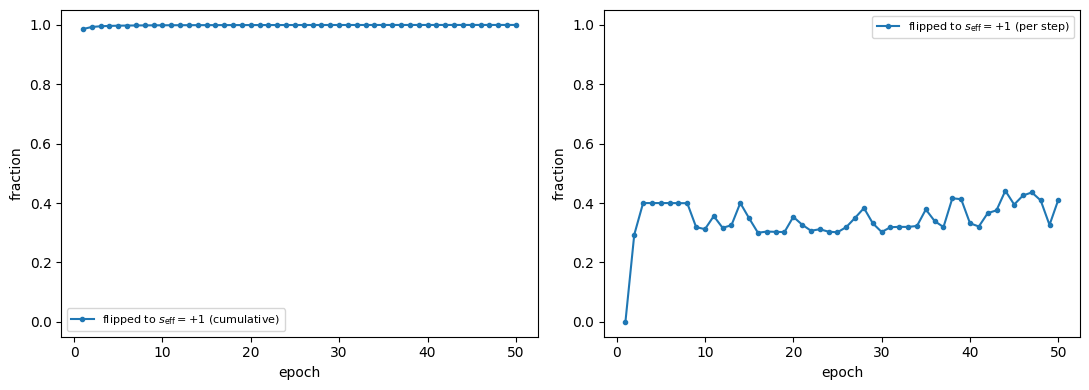

lCBOpt-LRD (s=-1): flipped to s_eff=+1 on 100.0% of steps ; strict feasibility failure 100.0% among s_eff=+1, 0.00% among s_eff=-1.
lCBOpt-BD (s=-1): flipped to s_eff=+1 on 34.5% of blocks (mean over steps) ; strict feasibility failure 99.8% among s_eff=+1, 0.00% among s_eff=-1.


In [ ]:
# Figure + print: s=-1 feasibility diagnostics before the psi regularizer (LRD cumulative, BD per-block).
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
summary = []
for ax, rid, _algo, cumulative in [(axes[0], 'lCBOpt-LRD', 'lCBOpt-LRD', True),
                                   (axes[1], 'lCBOpt-BD', 'lCBOpt-BD', False)]:
    h = hist(rid)
    if h is None:
        continue
    n_splus = h['n_splus']
    n_sm = h['n_sminus']
    n_sm_boom = h['n_sminus_infeasible']
    if rid == 'lCBOpt-LRD':
        flip_frac = h['flip_to_splus'] # per-step: n_splus in {0,1}
        n_boom = h['infeasible_sminus'] # per-step 0/1: u_sq >= 1/M
    else:
        flip_frac = h['flip_to_splus_frac'] # per-step fraction of blocks
        n_boom = h['infeasible_frac'] * h['n_blocks'] # mean # blocks with u_sq >= 1/M
    n_splus_boom = n_boom - n_sm_boom # infeasible blocks/steps in s_eff=+1

    flip_curve = flip_frac.expanding().mean() if cumulative else flip_frac
    fail_splus = (n_splus_boom / n_splus.replace(0, np.nan)).fillna(0.0)
    fail_sminus = (n_sm_boom / n_sm.replace(0, np.nan)).fillna(0.0)

    tag = 'cumulative' if cumulative else 'per step'
    ax.plot(h['epoch'], flip_curve, marker='.',
            label=f'flipped to $s_{{\\mathrm{{eff}}}}=+1$ ({tag})')
    ax.set_xlabel('epoch'); ax.set_ylabel('fraction')
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8)

    summary.append((rid, _algo, float(flip_frac.mean()),
                    float(n_splus_boom.sum() / max(n_splus.sum(), 1e-12)),
                    float(n_sm_boom.sum() / max(n_sm.sum(), 1e-12))))
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'feasibility_by_seff.png'), dpi=130)
plt.show()

for rid, algo, flip_r, fs, fm in summary:
    unit = 'steps' if rid == 'lCBOpt-LRD' else 'blocks (mean over steps)'
    print(f'{rid} (s=-1): flipped to s_eff=+1 on {100 * flip_r:.1f}% of {unit} ; '
          f'strict feasibility failure {100 * fs:.1f}% among s_eff=+1, '
          f'{100 * fm:.2f}% among s_eff=-1.')

In [ ]:
# psi: initial (Thm pd_plus/pd_minus, analytical) vs final (from the saved optimizer state), no figure.
for rid in ('uCBOpt-BD', 'lCBOpt-LRD', 'lCBOpt-BD'):
    cfg = RUN_CONFIGS[rid]['cfg']
    sign = RUN_CONFIGS[rid]['sign']
    h0, delta, a = cfg['hess_init'], cfg['weight_decay'], cfg['a']
    varphi = cfg.get('varphi', 2.0)
    m0 = h0 + delta
    psi_0 = 1.0 / m0 + a if sign == 1 else (1.0 / m0) / varphi

    finals = []
    for sd in agg_seeds(rid):
        pt, _ = ckpt_paths(rid, sd)
        if not os.path.exists(pt):
            continue
        ck = torch.load(pt, map_location='cpu', weights_only=False)
        opt = ck['opt']
        if 'psi' in opt['param_groups'][0]: # CBOptLRD: one global psi
            finals.append(float(opt['param_groups'][0]['psi']))
        else: # CBOptBlock: psi_bd per block
            block_psis = [float(st['psi_bd']) for st in opt['state'].values()]
            finals.append(sum(block_psis) / len(block_psis))

    if not finals:
        print(f'{rid}: no checkpoint found on disk, skipping.')
        continue
    psi_final = sum(finals) / len(finals)
    if psi_final > psi_0 * 1.01:
        trend = 'increased'
    elif psi_final < psi_0 * 0.99:
        trend = 'decreased'
    else:
        trend = 'stayed stable'
    unit = 'seed' if rid == 'lCBOpt-LRD' else 'seed(s) x blocks'
    print(f'{rid} (s={sign:+d}): psi_0 = {psi_0:.4f} (analytical)  ->  '
          f'psi_final = {psi_final:.4f} (mean over {len(finals)} {unit})')
    print(f'  psi {trend} from initialization to the end of training.')

uCBOpt-BD (s=+1): psi_0 = 20.2308 (analytical)  ->  psi_final = 29.7433 (mean over 2 seed(s) x blocks)
  psi increased from initialization to the end of training.
lCBOpt-LRD (s=-1): psi_0 = 4.9020 (analytical)  ->  psi_final = 13.0548 (mean over 1 seed)
  psi increased from initialization to the end of training.
lCBOpt-BD (s=-1): psi_0 = 4.9020 (analytical)  ->  psi_final = 8.8161 (mean over 1 seed(s) x blocks)
  psi increased from initialization to the end of training.


## SAM: learned radius (adaptive) vs fixed radius

6 independent runs, 1 seed x 50 epochs, no trajectory injection.
- **lCBO-iso_1/2/3** possibilistic iso, s=-1, with r = {1, 0.95, 1.05} x R_NOM_LOW. lCBO-iso_1 logs the full
  rho*_t = vartheta_t^-1/2 trajectory (per-step); rho_bar_nom = its temporal mean.
- **SAM_1/2/3** standard SAM with rho = {1, 0.95, 1.05} x rho_bar_nom.
- Delta_adapt = |Acc(lCBO-iso_3) - Acc(lCBO-iso_2)|, Delta_SAM = |Acc(SAM_3) - Acc(SAM_2)|, ratio =
  Delta_SAM / Delta_adapt. lCBO-iso_1 also feeds the L_Phi s=-1 figure.

In [ ]:
train_run('lCBO-iso_1')

lCBO-iso_1 seed=0 - training (cbopt_iso, sign=-1, 50 epochs, r=5.00e-01)...
epoch 1/50 train=2.3001 val=2.2917 best=2.2917
epoch 10/50 train=0.4355 val=0.4399 best=0.4399
epoch 20/50 train=0.3308 val=0.3425 best=0.3425
epoch 30/50 train=0.2920 val=0.3295 best=0.3196
epoch 40/50 train=0.2711 val=0.3039 best=0.3039
epoch 50/50 train=0.2636 val=0.3022 best=0.3022
  saved lcbo-iso_1_iso_sminus_seed0.pt (50 epochs)


In [ ]:
train_run('lCBO-iso_2')

lCBO-iso_2 seed=0 - training (cbopt_iso, sign=-1, 50 epochs, r=4.75e-01)...
epoch 1/50 train=2.3009 val=2.2936 best=2.2936
epoch 10/50 train=0.4483 val=0.4519 best=0.4519
epoch 20/50 train=0.3391 val=0.3510 best=0.3510
epoch 30/50 train=0.2993 val=0.3353 best=0.3254
epoch 40/50 train=0.2788 val=0.3079 best=0.3079
epoch 50/50 train=0.2715 val=0.3059 best=0.3059
  saved lcbo-iso_2_iso_sminus_seed0.pt (50 epochs)


In [ ]:
train_run('lCBO-iso_3')

lCBO-iso_3 seed=0 - training (cbopt_iso, sign=-1, 50 epochs, r=5.25e-01)...
epoch 1/50 train=2.2992 val=2.2894 best=2.2894
epoch 10/50 train=0.4250 val=0.4350 best=0.4324
epoch 20/50 train=0.3233 val=0.3380 best=0.3380
epoch 30/50 train=0.2848 val=0.3256 best=0.3169
epoch 40/50 train=0.2633 val=0.2986 best=0.2986
epoch 50/50 train=0.2553 val=0.2965 best=0.2965
  saved lcbo-iso_3_iso_sminus_seed0.pt (50 epochs)


In [ ]:
rbn = rho_bar_nom()
print(f'rho_bar_nom (temporal mean of vartheta_t^-1/2 along lCBO-iso_1) = {rbn:.5g}')

rho_bar_nom (temporal mean of vartheta_t^-1/2 along lCBO-iso_1) = 2.2165


In [ ]:
train_run('SAM_1')

SAM_1 seed=0 - training (sam, sign=None, 50 epochs, rho=2.217)...
epoch 1/50 train=2.3026 val=2.3027 best=2.3027
epoch 10/50 train=2.3025 val=2.3032 best=2.3025
epoch 20/50 train=2.3022 val=2.3023 best=2.3021
epoch 30/50 train=2.3016 val=2.3018 best=2.3015
epoch 40/50 train=2.3009 val=2.3010 best=2.3010
epoch 50/50 train=2.3007 val=2.3009 best=2.3009
  saved sam_1_sam_none_seed0.pt (50 epochs)


In [ ]:
train_run('SAM_2')

SAM_2 seed=0 - training (sam, sign=None, 50 epochs, rho=2.106)...
epoch 1/50 train=2.3026 val=2.3027 best=2.3027
epoch 10/50 train=2.3025 val=2.3032 best=2.3025
epoch 20/50 train=2.3023 val=2.3024 best=2.3021
epoch 30/50 train=2.3019 val=2.3021 best=2.3019
epoch 40/50 train=2.3015 val=2.3017 best=2.3017
epoch 50/50 train=2.3014 val=2.3016 best=2.3016
  saved sam_2_sam_none_seed0.pt (50 epochs)


In [ ]:
train_run('SAM_3')

SAM_3 seed=0 - training (sam, sign=None, 50 epochs, rho=2.327)...
epoch 1/50 train=2.3027 val=2.3028 best=2.3028
epoch 10/50 train=2.3025 val=2.3032 best=2.3025
epoch 20/50 train=2.3020 val=2.3021 best=2.3019
epoch 30/50 train=2.3008 val=2.3010 best=2.3009
epoch 40/50 train=2.2999 val=2.3000 best=2.3000
epoch 50/50 train=2.2996 val=2.2998 best=2.2998
  saved sam_3_sam_none_seed0.pt (50 epochs)


In [ ]:
# SAM final metrics
rbn = rho_bar_nom()
acc = {rid: run_accuracy(rid) for rid in ['lCBO-iso_1', 'lCBO-iso_2', 'lCBO-iso_3', 'SAM_1', 'SAM_2', 'SAM_3']}
d_adapt = abs(acc['lCBO-iso_3'] - acc['lCBO-iso_2'])
d_sam = abs(acc['SAM_3'] - acc['SAM_2'])
ratio = (d_sam / d_adapt) if d_adapt > 0 else float('nan')

print(f'rho_bar_nom = {rbn:.5g}')
print('accuracies:')
for rid in ['lCBO-iso_1', 'lCBO-iso_2', 'lCBO-iso_3', 'SAM_1', 'SAM_2', 'SAM_3']:
    kind = 'adaptive iso s=-1' if rid in ('lCBO-iso_1', 'lCBO-iso_2', 'lCBO-iso_3') else 'fixed SAM'
    mult = RUN_CONFIGS[rid].get('r_mult', RUN_CONFIGS[rid].get('rho_mult'))
    print(f'  {rid} ({kind}, x{mult}): Acc = {acc[rid]:.4f}')
print(f'\nDelta_adapt = |Acc(lCBO-iso_3) - Acc(lCBO-iso_2)| = {d_adapt:.4f}')
print(f'Delta_SAM   = |Acc(SAM_3) - Acc(SAM_2)| = {d_sam:.4f}')
if np.isfinite(ratio):
    print(f'ratio = Delta_SAM / Delta_adapt = {ratio:.2f}x')
else:
    print('ratio = Delta_SAM / Delta_adapt = undefined (Delta_adapt = 0)')

pd.DataFrame([dict(rho_bar_nom=rbn, **{f'Acc_{k}': v for k, v in acc.items()},
                   Delta_adapt=d_adapt, Delta_SAM=d_sam, ratio=ratio)]
             ).to_csv(os.path.join(RES_DIR, 'sam_radius_sensitivity.csv'), index=False)

rho_bar_nom = 2.2165
accuracies:
  lCBO-iso_1 (adaptive iso s=-1, x1.0): Acc = 0.8876
  lCBO-iso_2 (adaptive iso s=-1, x0.95): Acc = 0.8865
  lCBO-iso_3 (adaptive iso s=-1, x1.05): Acc = 0.8904
  SAM_1 (fixed SAM, x1.0): Acc = 0.2168
  SAM_2 (fixed SAM, x0.95): Acc = 0.1373
  SAM_3 (fixed SAM, x1.05): Acc = 0.2399

Delta_adapt = |Acc(lCBO-iso_3) - Acc(lCBO-iso_2)| = 0.0039
Delta_SAM   = |Acc(SAM_3) - Acc(SAM_2)| = 0.1026
ratio = Delta_SAM / Delta_adapt = 26.31x


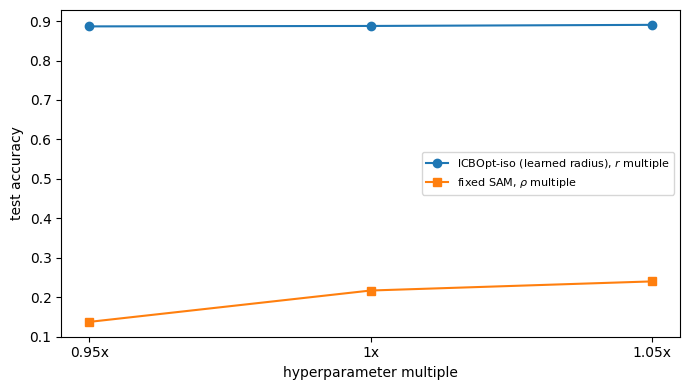

In [ ]:
# Figure: accuracy dispersion, adaptive (lCBO-iso_1/2/3) vs fixed SAM (SAM_1/2/3)
acc = {rid: run_accuracy(rid) for rid in ['lCBO-iso_1', 'lCBO-iso_2', 'lCBO-iso_3', 'SAM_1', 'SAM_2', 'SAM_3']}
fig, ax = plt.subplots(figsize=(7, 4))
mults = [0.95, 1.0, 1.05]
ax.plot(mults, [acc['lCBO-iso_2'], acc['lCBO-iso_1'], acc['lCBO-iso_3']], 'o-', label='lCBOpt-iso (learned radius), $r$ multiple')
ax.plot(mults, [acc['SAM_2'], acc['SAM_1'], acc['SAM_3']], 's-', label='fixed SAM, $\\rho$ multiple')
ax.set_xticks(mults); ax.set_xticklabels(['0.95x', '1x', '1.05x'])
ax.set_xlabel('hyperparameter multiple'); ax.set_ylabel('test accuracy')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'sam_radius_sensitivity.png'), dpi=130)
plt.show()

In [ ]:
# SAM = lCBO indicator (Prop sam_indicator): compare the one-step eps*_SAM with the PGA sup over the rho-ball, on an existing checkpoint.
import torch.nn as nn

def _pick_ckpt():
    for rid in ['uCBOpt-iso', 'uCBOpt-diag', 'uCBOpt-BD', 'lCBOpt-LRD', 'lCBOpt-BD']:
        p, _ = ckpt_paths(rid, 0)
        if os.path.exists(p):
            return p, rid
    return None, None

pt, rid = _pick_ckpt()
if pt is None:
    print('no checkpoint available yet -- run Section 2 first.')
else:
    print(f'using checkpoint: {rid}')
    _, _, te = loaders(0)
    xb, yb = next(iter(te))
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    model = LeNet(num_classes=10).to(DEVICE)
    model.load_state_dict(torch.load(pt, map_location=DEVICE)['model'])
    crit = nn.CrossEntropyLoss()
    base = [p.detach().clone() for p in model.parameters()]

    def restore():
        for p, b in zip(model.parameters(), base):
            p.data.copy_(b)

    def cur_loss():
        with torch.no_grad():
            return float(crit(model(xb), yb))

    def grad_flat():
        model.zero_grad()
        crit(model(xb), yb).backward()
        return torch.cat([p.grad.reshape(-1) for p in model.parameters()])

    def project(rho):
        dev = torch.cat([(p.detach() - b).reshape(-1) for p, b in zip(model.parameters(), base)])
        nrm = float(dev.norm())
        if nrm > rho:
            for p, b in zip(model.parameters(), base):
                p.data.copy_(b + (p.detach() - b) * (rho / nrm))

    for rho in (0.02, 0.05, 0.1):
        restore()
        g = grad_flat()
        off = 0
        with torch.no_grad():
            for p in model.parameters():
                n = p.numel()
                p.add_((rho / (g.norm() + 1e-12)) * g[off:off + n].view_as(p))
                off += n
        e_sam_1 = cur_loss()
        restore()
        for _ in range(25):
            gg = grad_flat()
            off = 0
            with torch.no_grad():
                for p in model.parameters():
                    n = p.numel()
                    p.add_((0.5 * rho / (gg.norm() + 1e-12)) * gg[off:off + n].view_as(p))
                    off += n
            project(rho)
        sup_pga = cur_loss()
        restore()
        print(f'rho={rho}: sup ell (PGA) = {sup_pga:.6f}   ell(eta+eps*_SAM) = {e_sam_1:.6f}   '
              f'-LCBO(indicator) = {-sup_pga:.6f}   |PGA - 1step| = {abs(sup_pga - e_sam_1):.2e}')

using checkpoint: uCBOpt-iso
rho=0.02: sup ell (PGA) = 0.320508   ell(eta+eps*_SAM) = 0.318723   -LCBO(indicator) = -0.320508   |PGA - 1step| = 1.79e-03
rho=0.05: sup ell (PGA) = 0.394040   ell(eta+eps*_SAM) = 0.371467   -LCBO(indicator) = -0.394040   |PGA - 1step| = 2.26e-02
rho=0.1: sup ell (PGA) = 0.589718   ell(eta+eps*_SAM) = 0.477218   -LCBO(indicator) = -0.589718   |PGA - 1step| = 1.12e-01


## Picard contraction constant 

`lphi_real` (exact |Phi'|, Rem lphi_explicit) and `lphi_bound_real` (the explicit
bound 2 d ||g||^2 / (u_min^4 a_min^3)) vs epoch, log-y, with the y=1 contraction
threshold (Thm picard). One figure for s=+1 (uCBOpt-iso), one for s=-1 (lCBO-iso_1).

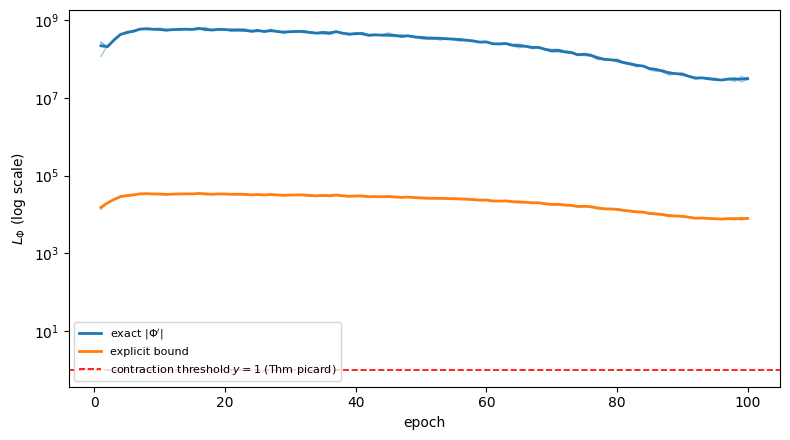

L_Phi s=+1 (uCBOpt-iso): lphi_real final-epoch mean = 3.142e+07, max = 6.192e+08.
  lphi_real exceeds 1 persistently from epoch 1 onward (bound uninformative there, Rem lphi_explicit).


In [ ]:
# L_Phi figure, s=+1, source uCBOpt-iso (3 seeds x 100 epochs)
frames = [hist('uCBOpt-iso', sd) for sd in RUN_CONFIGS['uCBOpt-iso']['seeds']]
frames = [f for f in frames if f is not None and 'lphi_real' in f.columns]
if not frames:
    print('uCBOpt-iso history not available (or missing lphi_real column).')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for f in frames:
        ax.plot(f['epoch'], f['lphi_real'], color='C0', alpha=0.4, lw=1)
        ax.plot(f['epoch'], f['lphi_bound_real'], color='C1', alpha=0.4, lw=1)
    big = pd.concat(frames)
    g = big.groupby('epoch')
    ax.plot(g['lphi_real'].mean().index, g['lphi_real'].mean(), color='C0', lw=2,
            label='exact $|\\Phi\'|$')
    ax.plot(g['lphi_bound_real'].mean().index, g['lphi_bound_real'].mean(), color='C1', lw=2,
            label='explicit bound')
    ax.axhline(1.0, color='red', ls='--', lw=1.2, label='contraction threshold $y=1$ (Thm picard)')
    ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('$L_\\Phi$ (log scale)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'lphi_splus_uCBOpt-iso.png'), dpi=130)
    plt.show()

    lr = big.groupby('epoch')['lphi_real'].mean()
    over = lr[lr > 1.0]
    persist = None
    if len(over):
        e = over.index[0]
        if (lr.loc[e:] > 1.0).all():
            persist = int(e)
    print(f'L_Phi s=+1 (uCBOpt-iso): lphi_real final-epoch mean = {lr.iloc[-1]:.4g}, '
          f'max = {lr.max():.4g}.')
    if persist is not None:
        print(f'  lphi_real exceeds 1 persistently from epoch {persist} onward '
              f'(bound uninformative there, Rem lphi_explicit).')
    else:
        print('  lphi_real stayed below 1 for the whole run '
              '(no persistent exceedance).' if lr.max() <= 1.0 else
              '  lphi_real exceeded 1 only transiently, not persistently.')

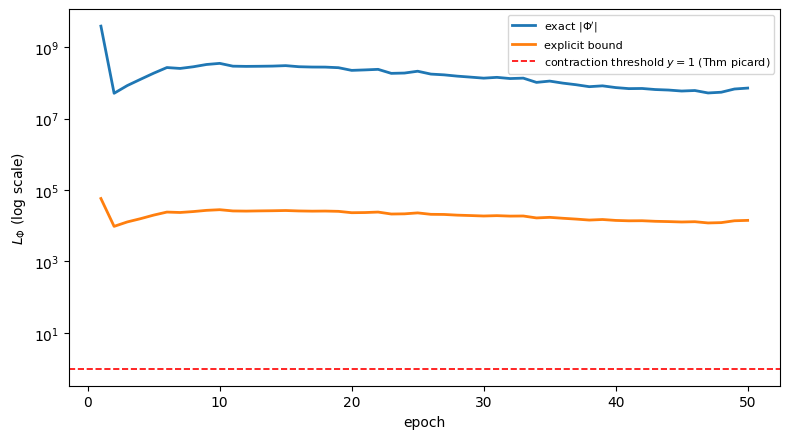

L_Phi s=-1 (lCBO-iso_1): lphi_real final-epoch = 7.175e+07, max = 3.901e+09.
  lphi_real exceeds 1 persistently from epoch 1 onward.


In [ ]:
# L_Phi figure, s=-1, source lCBO-iso_1 (1 seed x 50 epochs, reduced)
f = hist('lCBO-iso_1', 0)
if f is None or 'lphi_real' not in f.columns:
    print('lCBO-iso_1 history not available -- run Section 4 first.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(f['epoch'], f['lphi_real'], color='C0', lw=2, label='exact $|\\Phi\'|$')
    ax.plot(f['epoch'], f['lphi_bound_real'], color='C1', lw=2, label='explicit bound')
    ax.axhline(1.0, color='red', ls='--', lw=1.2, label='contraction threshold $y=1$ (Thm picard)')
    ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('$L_\\Phi$ (log scale)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'lphi_sminus_lCBO-iso_1.png'), dpi=130)
    plt.show()

    lr = f.set_index('epoch')['lphi_real']
    over = lr[lr > 1.0]
    persist = None
    if len(over) and (lr.loc[over.index[0]:] > 1.0).all():
        persist = int(over.index[0])
    print(f'L_Phi s=-1 (lCBO-iso_1): lphi_real final-epoch = {lr.iloc[-1]:.4g}, max = {lr.max():.4g}.')
    if persist is not None:
        print(f'  lphi_real exceeds 1 persistently from epoch {persist} onward.')
    else:
        print('  lphi_real stayed below 1 for the whole run.' if lr.max() <= 1.0 else
              '  lphi_real exceeded 1 only transiently.')

In [ ]:
# Aggregated long-format CSV across all training units
frames = [pd.read_csv(f) for f in sorted(glob.glob(os.path.join(CKPT_DIR, '*_history.csv')))]
if frames:
    long_df = pd.concat(frames, ignore_index=True)
    long_df.to_csv(os.path.join(RES_DIR, 'diagnostics_long.csv'), index=False)
    print('diagnostics_long.csv:', long_df.shape)
    print('columns:', list(long_df.columns))